In [1]:
import argparse
import pathlib

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    cfg = get_ipython().config
    in_notebook = True
except NameError:
    in_notebook = False

In [2]:
def print_times(df, wait_column):
    if df[wait_column].sum() > 24 * 365:
        wait = df[wait_column].sum() / 24 / 365
        wait_units = "years"
    elif df[wait_column].sum() > 24:
        wait = df[wait_column].sum() / 24
        wait_units = "days"
    else:
        wait = df[wait_column].sum()
        wait_units = "hours"
    # round to two decimal places
    wait = round(wait, 2)
    return wait, wait_units


def SU_to_compute_time(SU):
    if SU > 24 * 365:
        compute_time = SU / 24 / 365
        compute_units = "years"
    elif SU > 24:
        compute_time = SU / 24
        compute_units = "days"
    else:
        compute_time = SU
        compute_units = "hours"
    # round to two decimal places
    compute_time = round(compute_time, 2)
    return compute_time, compute_units


def elapsed_time_to_hours(elapsed_time):
    if "-" in elapsed_time:
        days = int(elapsed_time.split("-")[0])
        elapsed_time = elapsed_time.split("-")[1]
        hours, minutes, seconds = elapsed_time.split(":")
        hours = int(hours)
        minutes = int(minutes)
        seconds = int(seconds)
        total_hours = days * 24 + hours + minutes / 60 + seconds / 3600
    else:
        hours, minutes, seconds = elapsed_time.split(":")
        hours = int(hours)
        minutes = int(minutes)
        seconds = int(seconds)
        total_hours = hours + minutes / 60 + seconds / 3600

    return total_hours

In [3]:
stats_file_dir = pathlib.Path("../slurm_stats_files").resolve(strict=True)
results_dir = pathlib.Path("../results").resolve()
results_dir.mkdir(exist_ok=True, parents=True)

In [4]:
if not in_notebook:
    # set up the argument parser
    parser = argparse.ArgumentParser(description="Slurm stats")

    parser.add_argument(
        "--days", type=int, required=True, help="Number of days to consider"
    )
    parser.add_argument("--user", type=str, required=True, help="User to consider")
    parser.add_argument(
        "--top_n",
        type=int,
        required=False,
        default=25,
        help="Number of top jobs to show",
    )
    args = parser.parse_args()

    days = args.days
    user = args.user
    n = args.top_n
else:
    days = 10000
    user = "michael.lippincott@xsede.org"
    n = 500


acct_file_path = pathlib.Path("../slurm_stats_files/").resolve(strict=True)
jobs_file_path = pathlib.Path("../slurm_stats_files/").resolve(strict=True)

In [5]:
# find the most recent file in the directory
acct_files = list(acct_file_path.glob("*accounts*"))
job_files = list(jobs_file_path.glob("*jobs*"))
# sort
acct_files.sort(reverse=True)
job_files.sort(reverse=True)
acct_file_path = acct_files[0]  # get the most recent accounts file
jobs_file_path = job_files[0]  # get the most recent jobs file

In [20]:
# load the job stats file
# sep by tab
df = pd.read_csv(jobs_file_path, skiprows=[0, 2], sep="\t", header=0)
while "  " in df.columns[0]:
    df.columns = df.columns.str.replace("  ", " ")
    df = df.replace("  ", " ", regex=True)
# replace "  " in all rows and columns with " "

# split all the columns
new_columns = df.columns[0].split(" ") + ["wait_units"]
# # # split the contents of the first column
df = df[df.columns[0]].str.split(" ", expand=True)
# rename the columns
df.columns = new_columns
# cast types
df["jobid"] = df["jobid"].astype(str)
df["jobname"] = df["jobname"].astype(str)
df["partition"] = df["partition"].astype(str)
df["qos"] = df["qos"].astype(str)
df["account"] = df["account"].astype(str)
df["cpus"] = df["cpus"].astype(int)
df["state"] = df["state"].astype(str)
df["start-date-time"] = df["start-date-time"].astype(str)
df["elapsed"] = df["elapsed"].astype(str)
df["wait"] = df["wait"].astype(float)
df["wait_units"] = df["wait_units"].astype(str)
df["hours_computed"] = df["elapsed"].apply(elapsed_time_to_hours)

# get the compute and wait time for the user for each partition type
hours_df = df.groupby("partition").agg({"hours_computed": "sum", "wait": "sum"})

hours_df["wait_ratio"] = hours_df["wait"] / hours_df["hours_computed"]
print(f"Compute and wait time for {user} by partition for the last {days} days")
print(hours_df)

Compute and wait time for michael.lippincott@xsede.org by partition for the last 10000 days
            hours_computed      wait  wait_ratio
partition                                       
aa100          1015.452500   85188.0   83.891664
acompile         90.065833       0.0    0.000000
al40              6.516944     657.0  100.814117
amem          11456.211667  160462.0   14.006550
ami100            0.191944       0.0    0.000000
amilan       153405.053611   41957.0    0.273505
amilan128c        3.502778       0.0    0.000000
atesting          0.055000       0.0    0.000000
atesting_+        6.298056       0.0    0.000000


In [7]:
# split the start-time-date into date and time
df["date"] = df["start-date-time"].str.split("T").str[0]
df["year"] = df["date"].str.split("-").str[0]
df["year_month"] = (
    df["date"].str.split("-").str[0] + "-" + df["date"].str.split("-").str[1]
)
df["year_month"] = df["year_month"].astype(str)
# get the total number of hours computed per date
grouped_by_date_df = df.groupby("date").agg({"hours_computed": "sum", "wait": "sum"})
grouped_by_date_df.reset_index(inplace=True)
grouped_by_year_df = df.groupby("year").agg({"hours_computed": "sum", "wait": "sum"})
grouped_by_year_df.reset_index(inplace=True)
grouped_by_year_month_df = df.groupby("year_month").agg(
    {"hours_computed": "sum", "wait": "sum"}
)
grouped_by_year_month_df.reset_index(inplace=True)

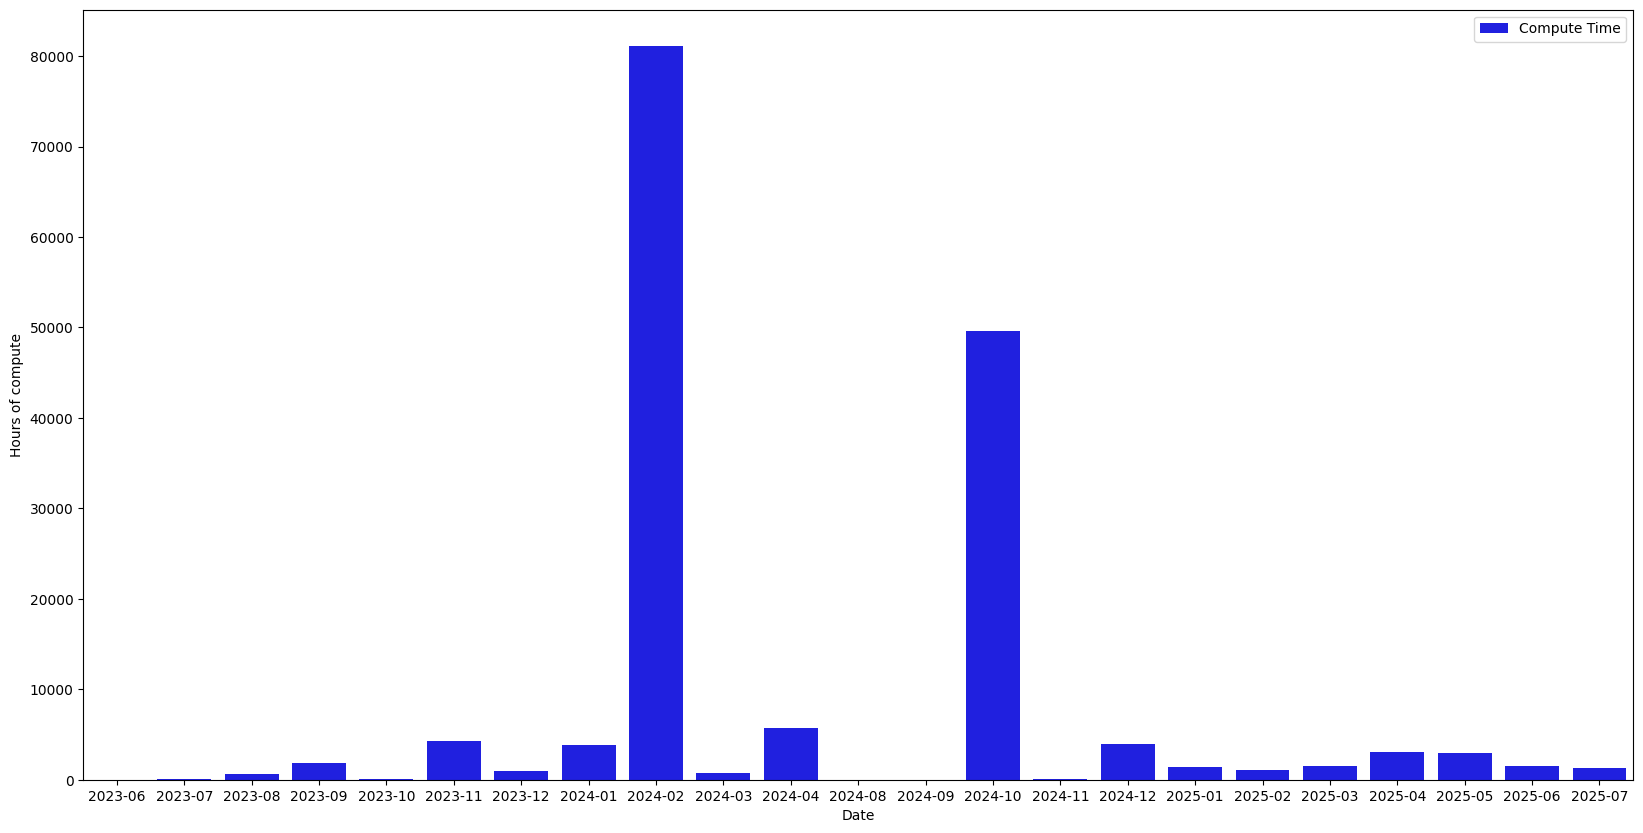

In [8]:
plt.figure(figsize=(20, 10))
sns.barplot(
    data=grouped_by_year_month_df,
    x="year_month",
    y="hours_computed",
    label="Compute Time",
    color="blue",
)
# change the labels
plt.xlabel("Date")
plt.ylabel("Hours of compute")
plt.show()

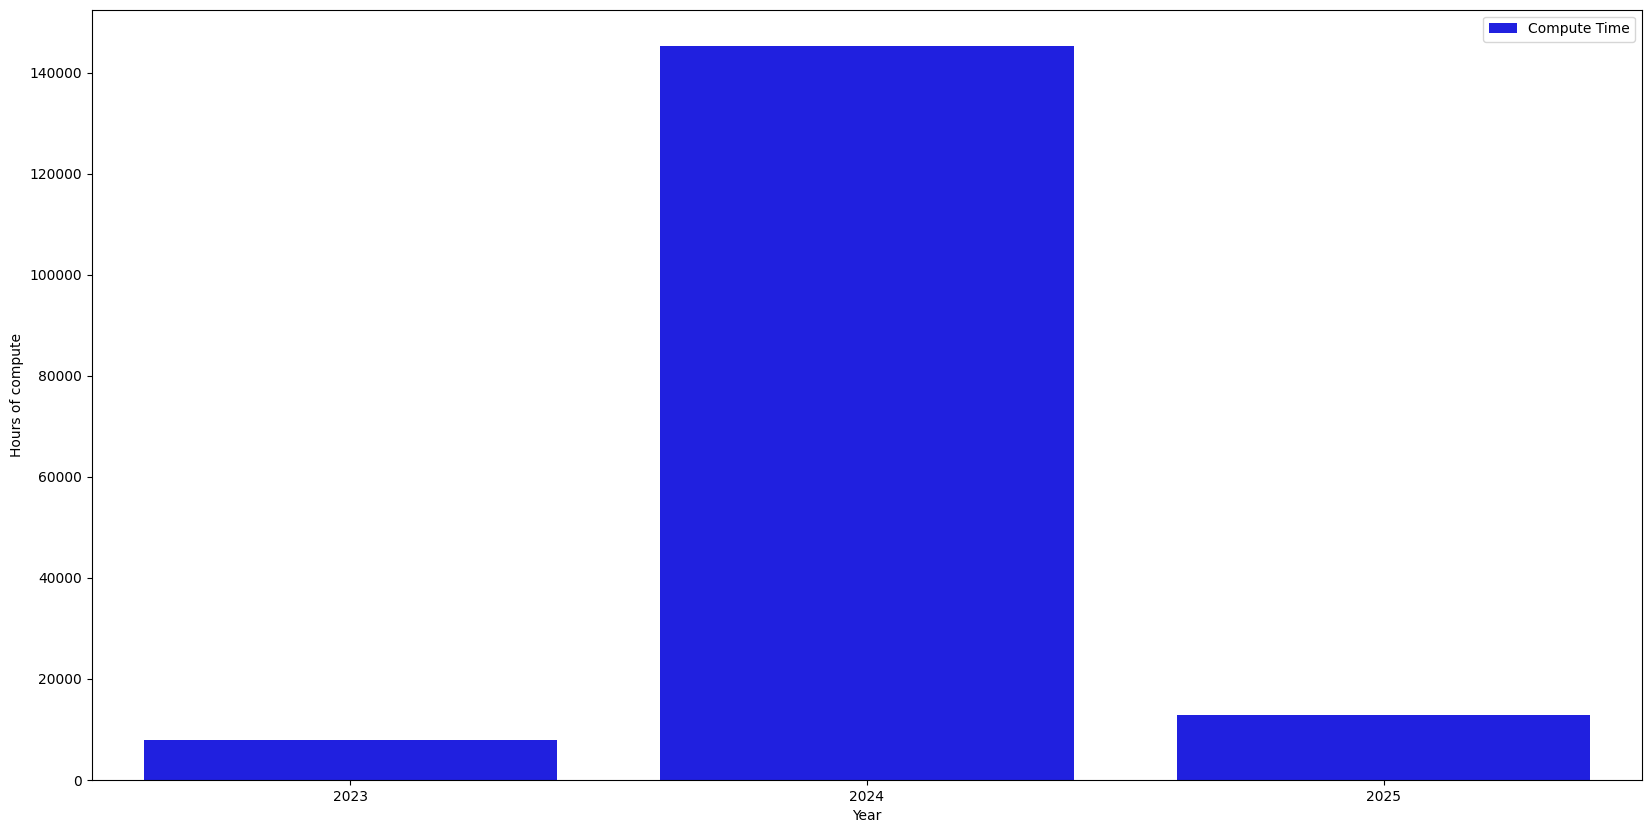

In [10]:
plt.figure(figsize=(20, 10))
sns.barplot(
    data=grouped_by_year_df,
    x="year",
    y="hours_computed",
    label="Compute Time",
    color="blue",
)
# change the labels
plt.xlabel("Year")
plt.ylabel("Hours of compute")
plt.show()